## Setup

In [1]:
import os
import sys
import json
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 30  # drop to 5-10 for a quick demo

print(f"Device: {DEVICE}")
print(f"Epochs: {EPOCHS}")

Device: cuda
Epochs: 30


In [2]:
qa_path = os.path.join(PROJECT_ROOT, "task2_chatbot", "data", "qa_pairs.json")
with open(qa_path, "r", encoding="utf-8") as f:
    qa_pairs = json.load(f)

print(f"Loaded {len(qa_pairs):,} QA pairs")

Loaded 2,250 QA pairs


## Shared tokenizer

Both chatbots use the **same vocabulary**, so we fit a single `WordTokenizer` over all questions + answers. The tokenizer also reserves four special tokens: `<PAD>` (0), `<UNK>` (1), `<SOS>` (2), `<EOS>` (3).

In [3]:
from task2_chatbot.train import build_tokenizer

tokenizer = build_tokenizer(qa_pairs)
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Special tokens:  PAD={tokenizer.pad_idx}, UNK={tokenizer.unk_idx}, "
      f"SOS={tokenizer.sos_idx}, EOS={tokenizer.eos_idx}")

sample_q = qa_pairs[0]["question"]
sample_a = qa_pairs[0]["answer"]
print(f"\nExample question: {sample_q!r}")
print(f"  encoded (with specials): {tokenizer.encode(sample_q, add_special=True)}")
print(f"Example answer:   {sample_a!r}")
print(f"  encoded (with specials): {tokenizer.encode(sample_a, add_special=True)}")

Vocabulary size: 1,515
Special tokens:  PAD=0, UNK=1, SOS=2, EOS=3

Example question: 'Could you answer: what is the capital of Mexico?'
  encoded (with specials): [2, 319, 1508, 80, 1473, 743, 1357, 198, 944, 864, 3]
Example answer:   'Well, The capital of Mexico is Mexico City.'
  encoded (with specials): [2, 1471, 1357, 198, 944, 863, 743, 863, 245, 3]


## Part 1 - LSTM seq2seq chatbot

**Architecture** (`task2_chatbot/models/lstm_chatbot.py`):

- **Encoder**: embedding (dim 128) → 2-layer bidirectional LSTM (hidden 256) → linear projections to merge the forward+backward hidden and cell states.
- **Attention**: Bahdanau-style additive attention over encoder outputs.
- **Decoder**: embedding → LSTM with concatenated `[embedded ⊕ context]` input → linear output over vocabulary (uses `[output ⊕ context ⊕ embedded]` for prediction).
- **Training**: teacher-forcing ratio decreasing from 1.0 → 0.5 over epochs, gradient clip at 1.0, Adam + StepLR.

In [4]:
from task2_chatbot.train import train_lstm_chatbot

lstm_chatbot, lstm_stats = train_lstm_chatbot(
    qa_pairs, tokenizer,
    batch_size=32, epochs=EPOCHS, lr=0.001, device=DEVICE,
)


--- Training LSTM Chatbot ---
  Epoch 1/30, Loss: 4.8924
  Epoch 5/30, Loss: 0.7984
  Epoch 10/30, Loss: 0.3355
  Epoch 15/30, Loss: 0.3102
  Epoch 20/30, Loss: 0.2446
  Epoch 25/30, Loss: 0.1267
  Epoch 30/30, Loss: 0.0812
  Training time: 124.32s
  Memory delta: 789.2 MB
  Final loss: 0.0812


In [5]:
print("--- LSTM chatbot sample responses ---\n")
for q in ["What is the capital of France?",
         "How does gravity work?",
         "Hello!",
         "What is a computer?"]:
    print(f"Q: {q}")
    print(f"A: {lstm_chatbot.respond(tokenizer, q, max_len=30, device=DEVICE)}")
    print("-" * 60)

--- LSTM chatbot sample responses ---

Q: What is the capital of France?
A: the capital of france is paris.
------------------------------------------------------------
Q: How does gravity work?
A: gravity works by creating an attractive force proportional to the masses involved.
------------------------------------------------------------
Q: Hello!
A: hello! how can i help you today?
------------------------------------------------------------
Q: What is a computer?
A: a computer is an electronic device that processes data according to instructions.
------------------------------------------------------------


## Part 2 - Transformer chatbot

In [6]:
from task2_chatbot.train import train_transformer_chatbot

trans_chatbot, trans_stats = train_transformer_chatbot(
    qa_pairs, tokenizer,
    batch_size=32, epochs=EPOCHS, lr=0.0005, device=DEVICE,
)


--- Training Transformer Chatbot ---
  Epoch 1/30, Loss: 7.4993
  Epoch 5/30, Loss: 6.5303
  Epoch 10/30, Loss: 5.6761
  Epoch 15/30, Loss: 5.1634
  Epoch 20/30, Loss: 4.8293
  Epoch 25/30, Loss: 4.5861
  Epoch 30/30, Loss: 4.3991
  Training time: 38.45s
  Memory delta: 74.0 MB
  Final loss: 4.3991


In [7]:
print("--- Transformer chatbot sample responses ---\n")
for q in ["What is the capital of France?",
         "How does gravity work?",
         "Hello!",
         "What is a computer?"]:
    print(f"Q: {q}")
    print(f"A: {trans_chatbot.respond(tokenizer, q, max_len=30, device=DEVICE)}")
    print("-" * 60)

--- Transformer chatbot sample responses ---

Q: What is the capital of France?
A: of course. the capital of course. the capital of course.
------------------------------------------------------------
Q: How does gravity work?
A: to answer that, a good question. a computer to the answer: a computer
------------------------------------------------------------
Q: Hello!
A: i can help with that. a good question. and is the process of a computer
------------------------------------------------------------
Q: What is a computer?
A: of course. a good question. a good question. a good question. a good question. a good question. a good question. a good question. a good question. a good question. a
------------------------------------------------------------


## Part 3 - Training loss curves

Side-by-side per-epoch training loss. Transformer typically drops faster thanks to parallel attention; LSTM starts higher and catches up more slowly.

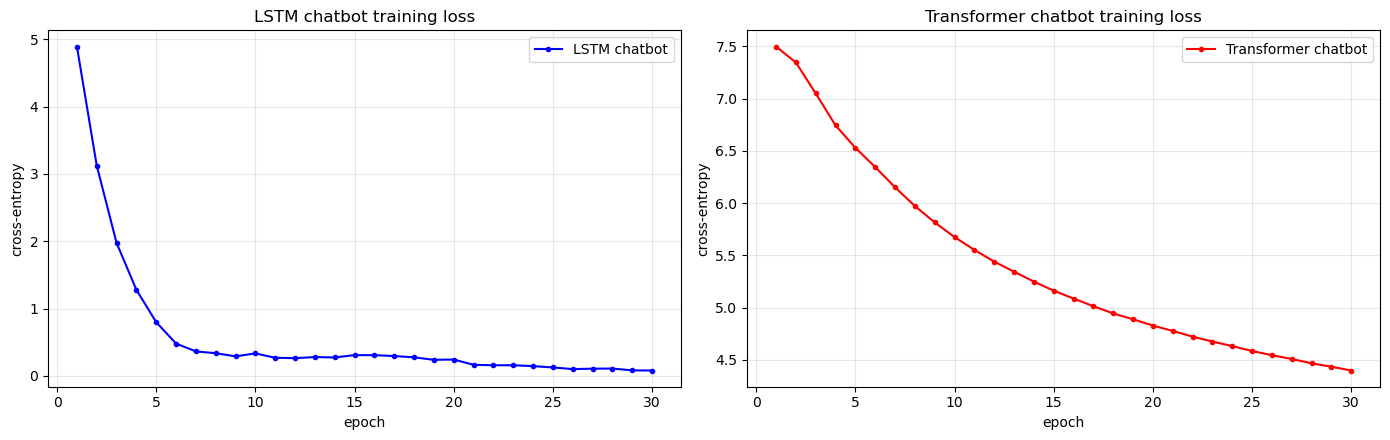


LSTM         final loss: 0.0812
Transformer  final loss: 4.3991


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(range(1, len(lstm_stats["losses"]) + 1), lstm_stats["losses"],
         "b-o", markersize=3, label="LSTM chatbot")
ax1.set_title("LSTM chatbot training loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy")
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(range(1, len(trans_stats["losses"]) + 1), trans_stats["losses"],
         "r-o", markersize=3, label="Transformer chatbot")
ax2.set_title("Transformer chatbot training loss")
ax2.set_xlabel("epoch"); ax2.set_ylabel("cross-entropy")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nLSTM         final loss: {lstm_stats['final_loss']:.4f}")
print(f"Transformer  final loss: {trans_stats['final_loss']:.4f}")

## Part 4 - Comparison across 10 test questions

We reuse `evaluate_chatbots` from `task2_chatbot/evaluate.py`. It runs a fixed set of 10 questions through both models, prints a perf summary (time / memory / params / final loss), and a side-by-side response table. It also writes `chatbot_loss_curves.png` to the project root.

In [9]:
from task2_chatbot.evaluate import evaluate_chatbots

chatbot_results = {
    "lstm_chatbot":        (lstm_chatbot,  lstm_stats),
    "transformer_chatbot": (trans_chatbot, trans_stats),
}

report = evaluate_chatbots(tokenizer, chatbot_results, device=DEVICE)

  Loss curves saved to: /home/arderd/nlp-from-scratch/task2_chatbot/chatbot_loss_curves.png

CHATBOT MODELS - TRAINING PERFORMANCE COMPARISON
+---------------------+-----------------+----------+--------------+--------------+
| Model               | Training Time   | Memory   |   Final Loss |   Parameters |
+=====================+=================+==========+==============+==============+
| LSTM Chatbot        | 124.32s         | 789.2 MB |       0.0812 |    6,019,947 |
+---------------------+-----------------+----------+--------------+--------------+
| Transformer Chatbot | 38.45s          | 74.0 MB  |       4.3991 |    1,971,819 |
+---------------------+-----------------+----------+--------------+--------------+

--- Loss Curves ---

CHATBOT MODELS - RESPONSE COMPARISON (10 TEST QUESTIONS)
+-----+--------------------------------+-------------------------------------+------------------------------------+
| #   | Question                       | LSTM Response                       | Tra

## Part 5 - Ask your own question

Edit `MY_QUESTION` and re-run this cell to compare both models' responses on any prompt.

In [10]:
MY_QUESTION = "What is photosynthesis?"

print(f"Q: {MY_QUESTION}\n")
print("LSTM chatbot:")
print(" ", lstm_chatbot.respond(tokenizer, MY_QUESTION, max_len=40, device=DEVICE))
print("\nTransformer chatbot:")
print(" ", trans_chatbot.respond(tokenizer, MY_QUESTION, max_len=40, device=DEVICE))

Q: What is photosynthesis?

LSTM chatbot:
  photosynthesis is the process by which plants convert sunlight into energy.

Transformer chatbot:
  of course. is the answer: is the answer: is a of course.
